In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
import emcee
import h5py
import corner
import matplotlib.pyplot as plt
import corner
import VBMicrolensing
VBM = VBMicrolensing.VBMicrolensing()
import tqdm
import math
import sys
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
JD0 = 0

In [2]:
from matplotlib import rcParams
rcParams["font.size"] = 15
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5

In [3]:
tref = 10063.874
coords = "17:57:38.03 -28:38:28.53"

VBM.t0_par = tref
VBM.parallaxsystem = 1
VBM.SetObjectCoordinates(coords)

In [4]:
def mag2flux(mag):
    return 10**(-mag / 2.5)

def flux2mag(flux):
    return -2.5 * np.log10(flux)

def linear_fit(x,y,w):
    w_sum = np.sum(w)
    wxy_sum = np.sum(w*x*y)
    wx_sum = np.sum(w*x)
    wy_sum = np.sum(w*y)
    wxx_sum = np.sum(w*x*x)
    bunbo = w_sum*wxx_sum-wx_sum**2
    a = (w_sum*wxy_sum-wx_sum*wy_sum)/bunbo
    b = (wxx_sum*wy_sum-wx_sum*wxy_sum)/bunbo
    y_fit = a * x + b
    chi2 = np.sum(w * (y - y_fit) ** 2)
    return a,b,chi2

cVIBoya = 0.50141358
dVIBoya = 0.41968496
EVI, AI = 1.483,  1.822
def calc_thS(_fs_I,_fs_v):
    I_S = flux2mag(_fs_I)
    V_S = flux2mag(_fs_v)
    VI_S = V_S - I_S
    
    I0_S = I_S - AI
    VI0_S = VI_S - EVI
    
    _theta_star  = 0.5*10**(cVIBoya + dVIBoya*VI0_S  - 0.2*I0_S)
    return _theta_star

def get_pr(theta):
    _t0,_tE,_u0,_q,_s,_theta,_rho = theta[0],theta[1],theta[2],theta[3],theta[4],theta[5],theta[6]
    _piEN, _piEE,_gamma1, _gamma2, _gamma3 = theta[7],theta[8],theta[9],theta[10],theta[11]
    _pr = [math.log(_s), math.log(_q), _u0, _theta, math.log(_rho), math.log(_tE), _t0+JD0, _piEN, _piEE, _gamma1,_gamma2,_gamma3]
    return _pr

def get_pr_wo_lom(theta):
    _t0,_tE,_u0,_q,_s,_theta,_rho = theta[0],theta[1],theta[2],theta[3],theta[4],theta[5],theta[6]
    _piEN, _piEE = theta[7],theta[8]
    _pr = [math.log(_s), math.log(_q), _u0, _theta, math.log(_rho), math.log(_tE), _t0+JD0, _piEN, _piEE]
    return _pr

def get_pr_wo_para(theta):
    _t0,_tE,_u0,_q,_s,_theta,_rho = theta[0],theta[1],theta[2],theta[3],theta[4],theta[5],theta[6]
    _pr = [math.log(_s), math.log(_q), _u0, _theta, math.log(_rho), math.log(_tE), _t0+JD0]
    return _pr

In [5]:
loaded = np.load("../simu_data/simu_data_05_kepler.npz", allow_pickle=True)

simu_data = {k: loaded[k] for k in loaded.files}

In [6]:
Is = 16 + AI
Vs = 1 + 18 + EVI
fs_I = mag2flux(Is)
fs_V = mag2flux(Vs)

t0_true = 10090
q_true = 0.01
u0_true = -0.02
alpha_true = -0.347735
tE_true = 151.64
rho_true = 0.00177562
s_true = 0.903443
piEN_true = 0.30033
piEE_true = -0.0714238
gamma1_true = -0.00125154
gamma2_true = 0.000376098
gamma3_true = -0.00356426
r_s_true = -0.141818
a_s_true = 0.954969

pr_true = [math.log(s_true), math.log(q_true), 
           u0_true, alpha_true, math.log(rho_true),
           math.log(tE_true), t0_true, piEN_true, piEE_true
           , gamma1_true,gamma2_true,gamma3_true,r_s_true,a_s_true]

In [7]:
print(pr_true)

[-0.10154225893113043, -4.605170185988091, -0.02, -0.347735, -6.333605621269677, 5.021509290648134, 10090, 0.30033, -0.0714238, -0.00125154, 0.000376098, -0.00356426, -0.141818, 0.954969]


In [8]:
np.array(pr_true) - np.array([-0.051293620644606734, -5.298317366548036, 0.01, 2.866703296400686, -9.320126510632791, 4.226910370411778, 2460085, np.float32(0.12885785), np.float32(0.13644081), np.float32(-0.0013762871), np.float32(-0.0021186606), np.float32(-0.0011440024), np.float32(-0.0003850853), np.float32(1.0774341)])
                             

array([-5.02486383e-02,  6.93147181e-01, -3.00000000e-02, -3.21443830e+00,
        2.98652089e+00,  7.94598920e-01, -2.44999500e+06,  1.71472149e-01,
       -2.07864614e-01,  1.24747080e-04,  2.49475860e-03, -2.42025758e-03,
       -1.41432915e-01, -1.22465063e-01])

In [9]:
color_map = {
    "MOA_Red": "cyan",
    "KMT-A_I": "blue",
    "KMT-C_I": "red",
    "KMT-S_I": "lightgreen",
}

color_map = {
    "MOA_Red": "C0",
    "KMT-A_I": "C1",
    "KMT-C_I": "C2",
    "KMT-S_I": "C3",
}

def classify_dataset(name):
    if "MOA_Red" in name:
        return "MOA_Red"
    elif "MOA_V" in name:
        return "MOA_V"
    elif "KMT-A" in name and "_I" in name:
        return "KMT-A_I"
    elif "KMT-A" in name and "_V" in name:
        return "KMT-A_V"
    elif "KMT-C" in name and "_I" in name:
        return "KMT-C_I"
    elif "KMT-C" in name and "_V" in name:
        return "KMT-C_V"
    elif "KMT-S" in name and "_I" in name:
        return "KMT-S_I"
    elif "KMT-S" in name and "_V" in name:
        return "KMT-S_V"
    else:
        return "other"

In [10]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # デフォルトで matplotlib に入ってる serif フォント
    "mathtext.fontset": "cm",        # 数式を LaTeX っぽく
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

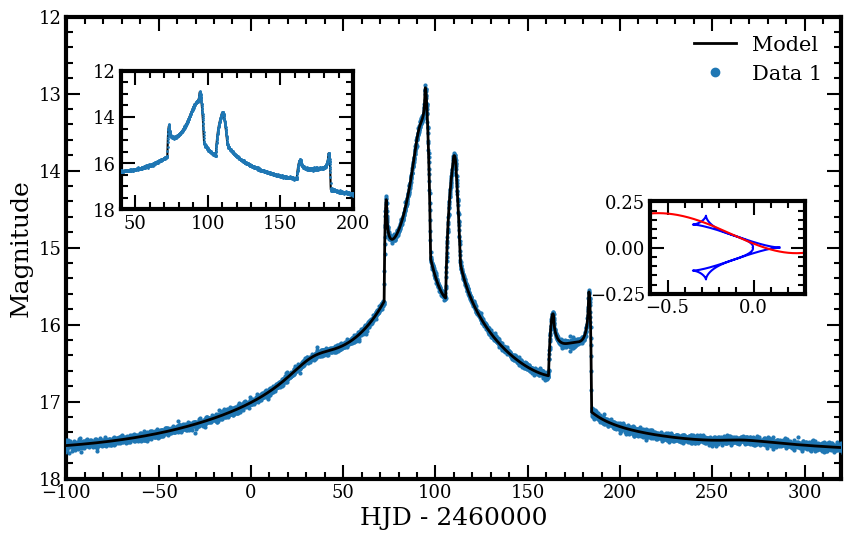

In [11]:
t_plot = np.linspace(9900,10320,10000)
amp_plot = np.array(VBM.BinaryLightCurveKepler(pr_true, t_plot)[0])

amp_plot = np.array(VBM.BinaryLightCurveKepler(pr_true, t_plot)[0])
mag_plot_I = flux2mag(amp_plot * fs_I + mag2flux(20))
mag_plot_V = flux2mag(amp_plot * fs_V + mag2flux(22))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_plot - JD0 - 10000, mag_plot_I, c="black", label="Model (I)", lw=2, zorder=10)

for i,name in enumerate(simu_data.keys()):
    group = classify_dataset(name)
    color = color_map.get(group, "gray")
    if "V" in name:
        continue
#     ax.errorbar(
#         simu_data[name]["time"] - 10000,
#         simu_data[name]["mag_obs"],
#         simu_data[name]["merr"],
#         fmt="o",
#         color=color,
#         markersize=4,
#         capsize=2,
#         alpha=1,
#         zorder=5-i
#     )
    ax.scatter(
        simu_data[name]["time"] - 10000,
        simu_data[name]["mag_obs"],
        color=color,
        s=4,
        alpha=1,
        zorder=5-i
    )

ax.set_xlim(-100, 320)
ax.set_ylim(12, 18)
ax.set_xlabel("HJD - 2460000", fontsize=18)
ax.set_ylabel("Magnitude", fontsize=18)
ax.invert_yaxis()
ax.minorticks_on()

custom_legend = [
    Line2D([0], [0], color="black", lw=2, label="Model"),
    Line2D([0], [0], marker='o', color="C0", linestyle='None', label="Data 1"),
#     Line2D([0], [0], marker='o', color="C1", linestyle='None', label="Data 2"),
#     Line2D([0], [0], marker='o', color="C2", linestyle='None', label="Data 3"),
#     Line2D([0], [0], marker='o', color="C3", linestyle='None', label="Data 4"),
]

ax.legend(handles=custom_legend, fontsize=15, frameon=False, loc="upper right")

axins = inset_axes(ax, width="30%", height="30%", loc="upper left", borderpad=3)
axins.plot(t_plot - JD0 - 10000, mag_plot_I, c="black", lw=1.5, zorder=0)

for i,name in enumerate(simu_data.keys()):
    group = classify_dataset(name)
    color = color_map.get(group, "gray")
    if "V" in name:
        continue
    times = simu_data[name]["time"] - 10000
    mags = simu_data[name]["mag_obs"]
    errs = simu_data[name]["merr"]

    mask = (times >= 0) & (times <= 250) & (mags >= 12) & (mags <= 18)
    if np.any(mask):
#         axins.errorbar(
#             times[mask],
#             mags[mask],
#             errs[mask],
#             fmt="o",
#             color=color,
#             markersize=1,
#             capsize=1,
#             alpha=1,
#             zorder=8-i
#         )
        axins.scatter(
            times[mask],
            mags[mask],
            color=color,
            s=1,
            alpha=1,
            zorder=8-i
        )

axins.set_xlim(40, 200)
axins.set_ylim(18, 12)

axins.minorticks_on()

ax_cau = inset_axes(ax, width="20%", height="20%", loc="center right", borderpad=2)

_, y1, y2, sorb = VBM.BinaryLightCurveKepler(pr_true, t_plot)
caustictimes = [5180]
colors = [(0, 0, 1, 1), "y", (0.6, 0, 0.4, 1)]

for i in range(1):
    caustics = VBM.Caustics(sorb[caustictimes[i]], np.exp(pr_true[1]))
    for cau in caustics:
        ax_cau.plot(cau[0], cau[1], color=colors[i])

ax_cau.plot(y1, y2, "red")

ax_cau.set_xlim(-0.6, 0.3)
ax_cau.set_ylim(-0.25, 0.25)
ax_cau.minorticks_on()

plt.savefig("/moao38_7/nunota/gapmoe/test_figures/simu_05_lc_kepler.pdf")

plt.show()